In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [3]:
data = pd.read_csv("student.csv")

# Display dataset
data.head()

,student_id,first_name,last_name,age,email,country,grade_math,grade_science,grade_english,Final_score
0,1,Kerrill,De Cleyne,24,kdecleyne0@furl.net,Venezuela,68,80,15,54
1,2,Krissie,Vittet,25,kvittet1@ustream.tv,Bulgaria,29,30,60,39
2,3,Hugibert,Haugg,21,hhaugg2@theguardian.com,New Zealand,76,0,55,43
3,4,Fancie,De Mars,18,fdemars3@parallels.com,China,82,88,90,86
4,5,Micki,O'Dowgaine,24,modowgaine4@livejournal.com,China,77,23,11,37


In [4]:
data.isnull().sum()

student_id       0
first_name       0
last_name        0
age              0
email            0
country          0
grade_math       0
grade_science    0
grade_english    0
Final_score      0
dtype: int64

In [5]:
text_columns = [
    'first_name',
    'last_name',
    'email',
    'country'
]

for col in text_columns:
    data[col] = data[col].astype('string')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   student_id     1000 non-null   int64 
 1   first_name     1000 non-null   string
 2   last_name      1000 non-null   string
 3   age            1000 non-null   int64 
 4   email          1000 non-null   string
 5   country        1000 non-null   string
 6   grade_math     1000 non-null   int64 
 7   grade_science  1000 non-null   int64 
 8   grade_english  1000 non-null   int64 
 9   Final_score    1000 non-null   int64 
dtypes: int64(6), string(4)
memory usage: 78.3 KB


In [10]:
scaler = StandardScaler()

In [13]:
numerical_columns = [
    'age',
    'grade_math',
    'grade_science',
    'grade_english',
    'Final_score',
]

In [14]:
scaled_values = scaler.fit_transform(
    data[numerical_columns]
)

In [15]:
scaled_df = pd.DataFrame(
    scaled_values,
    columns=[col + '_scaled' for col in numerical_columns]
)

In [16]:
standardized_data = pd.concat(
    [data, scaled_df],
    axis=1
)

In [17]:
standardized_data.head()

,student_id,first_name,last_name,age,email,country,grade_math,grade_science,grade_english,Final_score,age_scaled,grade_math_scaled,grade_science_scaled,grade_english_scaled,Final_score_scaled
0,1,Kerrill,De Cleyne,24,kdecleyne0@furl.net,Venezuela,68,80,15,54,1.083173,0.621849,1.083880,-1.192504,0.277437
1,2,Krissie,Vittet,25,kvittet1@ustream.tv,Bulgaria,29,30,60,39,1.522773,-0.729770,-0.627599,0.313436,-0.615792
2,3,Hugibert,Haugg,21,hhaugg2@theguardian.com,New Zealand,76,0,55,43,-0.235625,0.899104,-1.654487,0.146110,-0.377598
3,4,Fancie,De Mars,18,fdemars3@parallels.com,China,82,88,90,86,-1.554424,1.107045,1.357716,1.317396,2.182993
4,5,Micki,O'Dowgaine,24,modowgaine4@livejournal.com,China,77,23,11,37,1.083173,0.933761,-0.867206,-1.326365,-0.734890


In [18]:
standardized_data.describe()

,student_id,age,grade_math,grade_science,grade_english,Final_score,age_scaled,grade_math_scaled,grade_science_scaled,grade_english_scaled,Final_score_scaled
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03
mean,500.500000,21.536000,50.057000,48.335000,50.634000,49.341000,-6.199485e-16,-7.371881e-17,-4.263256e-17,-1.243450e-17,-6.394885e-17
std,288.819436,2.275936,28.868723,29.229114,29.896619,16.801399,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00
min,1.000000,18.000000,0.000000,0.000000,0.000000,7.000000,-1.554424e+00,-1.734820e+00,-1.654487e+00,-1.694484e+00,-2.521349e+00
25%,250.750000,20.000000,24.000000,24.000000,24.000000,37.000000,-6.752249e-01,-9.030548e-01,-8.329769e-01,-8.913157e-01,-7.348897e-01
50%,500.500000,21.000000,51.000000,47.000000,50.000000,49.500000,-2.356254e-01,3.268145e-02,-4.569649e-02,-2.121702e-02,9.468233e-03
75%,750.250000,23.000000,74.000000,74.000000,77.250000,62.000000,6.435737e-01,8.297901e-01,8.785022e-01,8.907133e-01,7.538262e-01
max,1000.000000,25.000000,100.000000,100.000000,100.000000,92.000000,1.522773e+00,1.730869e+00,1.768471e+00,1.652050e+00,2.540285e+00


In [19]:
standardized_data['country_code'] = (
    standardized_data['country']
    .astype('category')
    .cat.codes
)

In [20]:
standardized_data[[
    'country',
    'country_code'
]].head()

,country,country_code
0,Venezuela,113
1,Bulgaria,13
2,New Zealand,75
3,China,19
4,China,19


In [21]:
standardized_data.to_csv(
    'standardized_student_data.csv',
    index=False
)

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

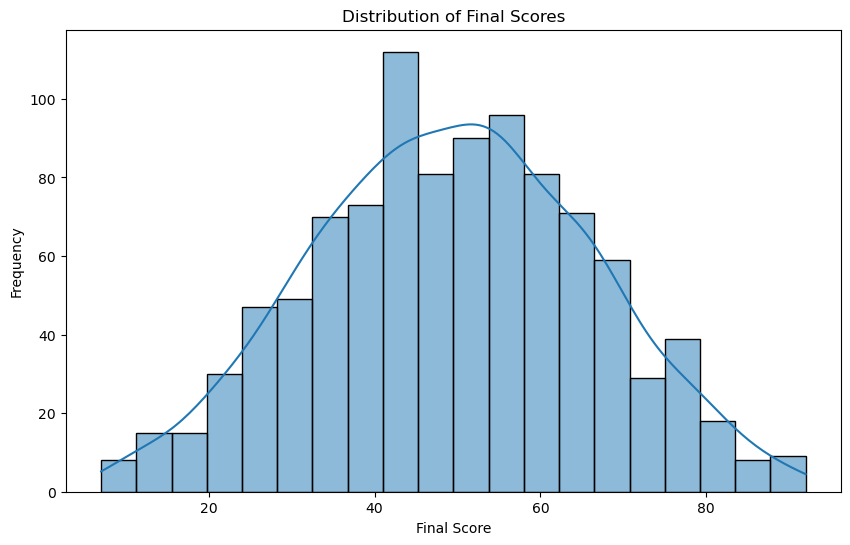

In [25]:
plt.figure(figsize=(10,6))

sns.histplot(
    standardized_data['Final_score'],
    bins=20,
    kde=True
)

plt.title('Distribution of Final Scores')
plt.xlabel('Final Score')
plt.ylabel('Frequency')

plt.show()

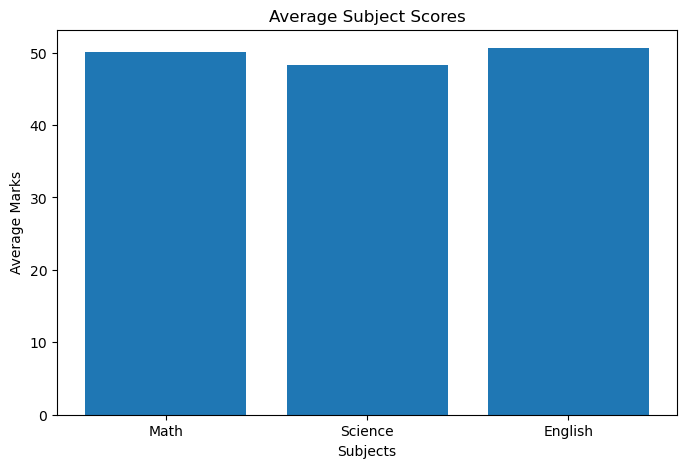

In [26]:
subject_means = [
    standardized_data['grade_math'].mean(),
    standardized_data['grade_science'].mean(),
    standardized_data['grade_english'].mean()
]

subjects = ['Math', 'Science', 'English']
plt.figure(figsize=(8,5))

plt.bar(subjects, subject_means)

plt.title('Average Subject Scores')
plt.xlabel('Subjects')
plt.ylabel('Average Marks')

plt.show()

In [27]:
standardized_data.head()

,student_id,first_name,last_name,age,email,country,grade_math,grade_science,grade_english,Final_score,age_scaled,grade_math_scaled,grade_science_scaled,grade_english_scaled,Final_score_scaled,country_code
0,1,Kerrill,De Cleyne,24,kdecleyne0@furl.net,Venezuela,68,80,15,54,1.083173,0.621849,1.083880,-1.192504,0.277437,113
1,2,Krissie,Vittet,25,kvittet1@ustream.tv,Bulgaria,29,30,60,39,1.522773,-0.729770,-0.627599,0.313436,-0.615792,13
2,3,Hugibert,Haugg,21,hhaugg2@theguardian.com,New Zealand,76,0,55,43,-0.235625,0.899104,-1.654487,0.146110,-0.377598,75
3,4,Fancie,De Mars,18,fdemars3@parallels.com,China,82,88,90,86,-1.554424,1.107045,1.357716,1.317396,2.182993,19
4,5,Micki,O'Dowgaine,24,modowgaine4@livejournal.com,China,77,23,11,37,1.083173,0.933761,-0.867206,-1.326365,-0.734890,19
